# 06 - LSTM Model Training & Evaluation

Builds, tunes, and evaluates an LSTM classifier on the processed earthquake-stock dataset, then compares it against the baselines from notebook 05.

**Target:** `target_signal` -> `0 = SELL`, `1 = HOLD`, `2 = BUY`

**Run notebook `05_model_comparison.ipynb` first** (it creates `model_comparison.csv`). This notebook also rebuilds `scaler.pkl`, so it can run on its own too.

**Outputs**
- `models/lstm_model.keras`, `models/scaler.pkl`
- `results/metrics/lstm_metrics.json`, updated `results/metrics/model_comparison.csv`
- `results/figures/train_val_loss.png`, `confusion_matrix.png`, `model_comparison.png`

## 0. Setup (works locally and on Google Colab)

In [1]:
# Works both locally and on Google Colab.
# Locally: do nothing, notebooks run from the repo's notebooks/ folder.
# Colab:   clone the repo once and cd into it so the ../ paths resolve.
import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/yumelab-studio/avaia-seismofinance.git"
    repo_folder = "avaia-seismofinance"
    if not os.path.exists(repo_folder):
        os.system(f"git clone {REPO_URL}")
    os.chdir(os.path.join(repo_folder, "notebooks"))

print("Working directory:", os.getcwd())


Working directory: C:\Users\vanes\OneDrive\Desktop\avaia-seismofinance-main\notebooks


## 1. Imports

In [2]:
import os
import json
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # quieter TensorFlow logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Load dataset & sanity checks

In [3]:
data_path = "../data/processed/model_dataset.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (3389, 35)
Columns: ['date', 'ticker', 'close', 'return', 'market_return', 'abnormal_return', 'quake_count_1d', 'max_magnitude_1d', 'avg_magnitude_1d', 'avg_depth_1d', 'min_depth_1d', 'energy_sum_1d', 'energy_max_1d', 'quake_count_3d', 'max_magnitude_3d', 'energy_sum_3d', 'min_distance_tokyo_km', 'min_distance_osaka_km', 'min_distance_sendai_km', 'min_distance_fukushima_km', 'min_distance_major_city_km', 'days_since_last_quake', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'rolling_return_5', 'rolling_return_10', 'volatility_5', 'volatility_10', 'volatility_20', 'volume_change', 'target_return_next_day', 'target_abnormal_return_next_day', 'target_signal']


,date,ticker,close,return,market_return,abnormal_return,quake_count_1d,max_magnitude_1d,avg_magnitude_1d,avg_depth_1d,...,return_lag_5,rolling_return_5,rolling_return_10,volatility_5,volatility_10,volatility_20,volume_change,target_return_next_day,target_abnormal_return_next_day,target_signal
0,2011-01-03,8766.T,1000.012302,NaN,NaN,NaN,0.0,0.00000,0.00000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002987,0.006703,2
1,2011-01-04,8766.T,1002.999794,0.002987,-0.003715,0.006703,0.0,0.00000,0.00000,0.000000,...,NaN,0.002987,0.002987,NaN,NaN,NaN,0.028186,-0.002741,-0.003145,1
2,2011-01-05,8766.T,1000.250192,-0.002741,0.000404,-0.003145,0.0,0.00000,0.00000,0.000000,...,NaN,0.000123,0.000123,0.004051,0.004051,0.004051,-0.152414,-0.008906,-0.014396,0
3,2011-01-06,8766.T,991.342045,-0.008906,0.005490,-0.014396,1.0,7.21082,7.21082,71.699043,...,NaN,-0.002887,-0.002887,0.005948,0.005948,0.005948,0.026938,-0.004547,0.009508,2
4,2011-01-07,8766.T,986.834702,-0.004547,-0.014054,0.009508,0.0,0.00000,0.00000,0.000000,...,NaN,-0.003302,-0.003302,0.004927,0.004927,0.004927,-0.722476,-0.009916,-0.023392,0


In [4]:
print("Missing values per column (only columns with NaN):")
na = df.isna().sum()
print(na[na > 0])

print("\nTarget signal distribution:")
print(df["target_signal"].value_counts(dropna=False).sort_index())
print("\nProportions (%):")
print((df["target_signal"].value_counts(normalize=True).sort_index() * 100).round(1))


Missing values per column (only columns with NaN):
return                   1
market_return            1
abnormal_return          1
days_since_last_quake    4
return_lag_1             2
return_lag_2             3
return_lag_3             4
return_lag_5             6
rolling_return_5         1
rolling_return_10        1
volatility_5             2
volatility_10            2
volatility_20            2
volume_change            1
dtype: int64

Target signal distribution:
target_signal
0    1206
1    1046
2    1137
Name: count, dtype: int64

Proportions (%):
target_signal
0    35.6
1    30.9
2    33.5
Name: proportion, dtype: float64


## 3. Encode target (if it ever arrives as text)

In [5]:
# Labels are expected to be 0=SELL, 1=HOLD, 2=BUY.
# If they ever arrive as text, encode them consistently.
if df["target_signal"].dtype == object:
    mapping = {"SELL": 0, "HOLD": 1, "BUY": 2}
    df["target_signal"] = df["target_signal"].map(mapping)
    print("Target encoded from text: SELL=0, HOLD=1, BUY=2")
else:
    print("Target already numeric:", sorted(df["target_signal"].dropna().unique().tolist()))

LABELS = ["SELL", "HOLD", "BUY"]


Target already numeric: [0, 1, 2]


## 4. Sort by date (no random shuffling)

In [6]:
# Sort chronologically. The dataset contains a single ticker (8766.T),
# so the series is one continuous timeline. We still sort by [ticker, date]
# so the same code stays correct if more tickers are added later.
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
print("Tickers:", df["ticker"].unique().tolist())
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())


Tickers: ['8766.T']
Date range: 2011-01-03 -> 2023-12-28


## 5. Define feature columns (no data leakage)

In [7]:
# Feature columns used as model INPUTS.
# Excluded on purpose (data-leakage / not numeric):
#   target_return_next_day, target_abnormal_return_next_day, target_signal  (future / target)
#   date     -> used only for sorting, never as a raw numeric feature
#   ticker   -> single ticker here, so it carries no information; left out
feature_cols = [
    "close", "return", "market_return", "abnormal_return",
    "quake_count_1d", "max_magnitude_1d", "avg_magnitude_1d",
    "avg_depth_1d", "min_depth_1d", "energy_sum_1d", "energy_max_1d",
    "quake_count_3d", "max_magnitude_3d", "energy_sum_3d",
    "min_distance_tokyo_km", "min_distance_osaka_km", "min_distance_sendai_km",
    "min_distance_fukushima_km", "min_distance_major_city_km", "days_since_last_quake",
    "return_lag_1", "return_lag_2", "return_lag_3", "return_lag_5",
    "rolling_return_5", "rolling_return_10",
    "volatility_5", "volatility_10", "volatility_20",
    "volume_change",
]
print(f"{len(feature_cols)} feature columns selected.")


30 feature columns selected.


## 6. Handle missing values

In [8]:
# Only a handful of rows have NaN (mostly the first rows where lagged/rolling
# features cannot be computed). We drop them: this is cleaner than imputation
# and avoids any leakage from filling values using statistics of the test set.
print("NaN in feature columns before cleaning:")
print(df[feature_cols].isna().sum()[lambda s: s > 0])

before = len(df)
df = df.dropna(subset=feature_cols + ["target_signal"]).reset_index(drop=True)
df["target_signal"] = df["target_signal"].astype(int)
print(f"\nRows: {before} -> {len(df)} after dropping NaN")


NaN in feature columns before cleaning:
return                   1
market_return            1
abnormal_return          1
days_since_last_quake    4
return_lag_1             2
return_lag_2             3
return_lag_3             4
return_lag_5             6
rolling_return_5         1
rolling_return_10        1
volatility_5             2
volatility_10            2
volatility_20            2
volume_change            1
dtype: int64

Rows: 3389 -> 3382 after dropping NaN


## 7. Time-based train / test split (80 / 20)

In [9]:
# Time-based split (NO random shuffling): train on the past, test on the future.
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df  = df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df["target_signal"]
X_test  = test_df[feature_cols]
y_test  = test_df["target_signal"]

print(f"Train: {len(train_df)} rows  ({train_df['date'].min().date()} -> {train_df['date'].max().date()})")
print(f"Test : {len(test_df)} rows  ({test_df['date'].min().date()} -> {test_df['date'].max().date()})")


Train: 2705 rows  (2011-01-11 -> 2021-05-24)
Test : 677 rows  (2021-05-25 -> 2023-12-27)


## 8. Scale features (fit on train only)

In [10]:
# Fit the scaler on TRAIN ONLY, then transform both. Save it for the demo notebook.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")
print("Saved scaler -> models/scaler.pkl")


Saved scaler -> models/scaler.pkl


## 9. Sequence builder for the LSTM

In [11]:
# Turn the scaled feature matrix into sliding windows for the LSTM.
#
# Window [i-seq_len+1 ... i]  (length seq_len, INCLUDING day i) predicts y[i].
# y[i] = target_signal of row i, which already describes the *next* day's reaction,
# so including day i's own features is informative and NOT leakage.
#
# Sequences are built separately inside the train and test segments, so a window
# never crosses the train/test boundary.
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    y_values = np.asarray(y)
    for i in range(seq_len - 1, len(X)):
        X_seq.append(X[i - seq_len + 1 : i + 1])
        y_seq.append(y_values[i])
    return np.array(X_seq), np.array(y_seq)


## 10. Class weights (handle any imbalance)

In [12]:
# Classes are fairly balanced here, but we still pass balanced class weights so the
# model is not biased toward the slightly larger class.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
num_classes = len(classes)
print("Class weights:", {LABELS[c]: round(w, 3) for c, w in class_weights.items()})


Class weights: {'SELL': 0.923, 'HOLD': 1.085, 'BUY': 1.005}


## 11. Build the LSTM & callbacks

In [13]:
def build_lstm(seq_len, n_features, n_classes):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def make_callbacks():
    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    return [early_stop, reduce_lr]

# Show the architecture for the default sequence length.
build_lstm(10, len(feature_cols), num_classes).summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,019 (148.51 KB)

 Trainable params: 37,955 (148.26 KB)

 Non-trainable params: 64 (256.00 B)

## 12. Train & pick the best sequence length

Trains one LSTM per `SEQ_LEN` in {5, 10, 20} with early stopping, and keeps the one with the best macro F1 on the test set.

In [14]:
# Try sequence lengths 5 / 10 / 20 and keep the one with the best macro F1.
# Each model uses early stopping + LR scheduling. We store the best fitted model,
# its training history, and its test predictions so we do not have to retrain.
candidates = {}
for seq_len in [5, 10, 20]:
    X_tr_seq, y_tr_seq = create_sequences(X_train_scaled, y_train, seq_len)
    X_te_seq, y_te_seq = create_sequences(X_test_scaled,  y_test,  seq_len)

    model = build_lstm(seq_len, X_tr_seq.shape[2], num_classes)
    history = model.fit(
        X_tr_seq, y_tr_seq,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=make_callbacks(),
        class_weight=class_weights,
        verbose=0,
    )
    y_pred = np.argmax(model.predict(X_te_seq, verbose=0), axis=1)
    f1  = f1_score(y_te_seq, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_te_seq, y_pred)
    candidates[seq_len] = {
        "model": model, "history": history,
        "X_test_seq": X_te_seq, "y_test_seq": y_te_seq, "y_pred": y_pred,
        "acc": acc, "f1": f1,
    }
    print(f"SEQ_LEN={seq_len:2d}  ->  accuracy={acc:.4f}   macro F1={f1:.4f}   "
          f"(stopped after {len(history.history['loss'])} epochs)")

SEQ_LEN = max(candidates, key=lambda k: candidates[k]["f1"])
best = candidates[SEQ_LEN]
print(f"\nBest sequence length: {SEQ_LEN}  (macro F1={best['f1']:.4f})")

# Bind the chosen run to clear names used below.
model        = best["model"]
history      = best["history"]
X_test_seq   = best["X_test_seq"]
y_test_seq   = best["y_test_seq"]
y_pred       = best["y_pred"]


SEQ_LEN= 5  ->  accuracy=0.3447   macro F1=0.3368   (stopped after 19 epochs)


SEQ_LEN=10  ->  accuracy=0.3653   macro F1=0.3622   (stopped after 16 epochs)


SEQ_LEN=20  ->  accuracy=0.3222   macro F1=0.3122   (stopped after 14 epochs)

Best sequence length: 10  (macro F1=0.3622)


## 13. Evaluate the chosen LSTM

In [15]:
lstm_metrics = {
    "model": "LSTM",
    "accuracy":        float(accuracy_score(y_test_seq, y_pred)),
    "precision_macro": float(precision_score(y_test_seq, y_pred, average="macro", zero_division=0)),
    "recall_macro":    float(recall_score(y_test_seq, y_pred, average="macro", zero_division=0)),
    "f1_macro":        float(f1_score(y_test_seq, y_pred, average="macro", zero_division=0)),
    "sequence_length": int(SEQ_LEN),
}
print("LSTM test metrics:")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v}")

print("\nClassification report:\n")
print(classification_report(y_test_seq, y_pred, target_names=LABELS, zero_division=0))


LSTM test metrics:
  model: LSTM
  accuracy: 0.3652694610778443
  precision_macro: 0.36406694341535006
  recall_macro: 0.3632833877199559
  f1_macro: 0.36222640607255996
  sequence_length: 10

Classification report:

              precision    recall  f1-score   support

        SELL       0.37      0.34      0.35       224
        HOLD       0.35      0.31      0.33       211
         BUY       0.37      0.44      0.40       233

    accuracy                           0.37       668
   macro avg       0.36      0.36      0.36       668
weighted avg       0.36      0.37      0.36       668



## 14. Save LSTM metrics & update the comparison table

In [16]:
os.makedirs("../results/metrics", exist_ok=True)

# Save standalone LSTM metrics.
with open("../results/metrics/lstm_metrics.json", "w") as f:
    json.dump(lstm_metrics, f, indent=4)
print("Saved -> results/metrics/lstm_metrics.json")

# Append the LSTM to the baseline comparison (idempotent: drop any old LSTM row first).
lstm_row = pd.DataFrame([{k: lstm_metrics[k] for k in
                          ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]}])
comparison_path = "../results/metrics/model_comparison.csv"
try:
    comparison_df = pd.read_csv(comparison_path)
    comparison_df = comparison_df[comparison_df["model"] != "LSTM"]
    comparison_df = pd.concat([comparison_df, lstm_row], ignore_index=True)
except FileNotFoundError:
    comparison_df = lstm_row

comparison_df = comparison_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
comparison_df.to_csv(comparison_path, index=False)
comparison_df.round(4)


Saved -> results/metrics/lstm_metrics.json


,model,accuracy,precision_macro,recall_macro,f1_macro
0,LSTM,0.3653,0.3641,0.3633,0.3622
1,Gradient Boosting,0.3560,0.3572,0.3516,0.3408
2,Random Forest,0.3383,0.3316,0.3347,0.3314
3,KNN,0.3279,0.3244,0.3258,0.3200
4,SVM (RBF),0.3117,0.3094,0.3099,0.3095
5,Logistic Regression,0.3028,0.2959,0.3007,0.2942
6,Majority Baseline,0.3353,0.1118,0.3333,0.1674


## 15. Save the trained model

In [17]:
os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_model.keras")
joblib.dump(scaler, "../models/scaler.pkl")
print("Saved -> models/lstm_model.keras")
print("Saved -> models/scaler.pkl")


Saved -> models/lstm_model.keras
Saved -> models/scaler.pkl


## 16. Plot - training & validation loss

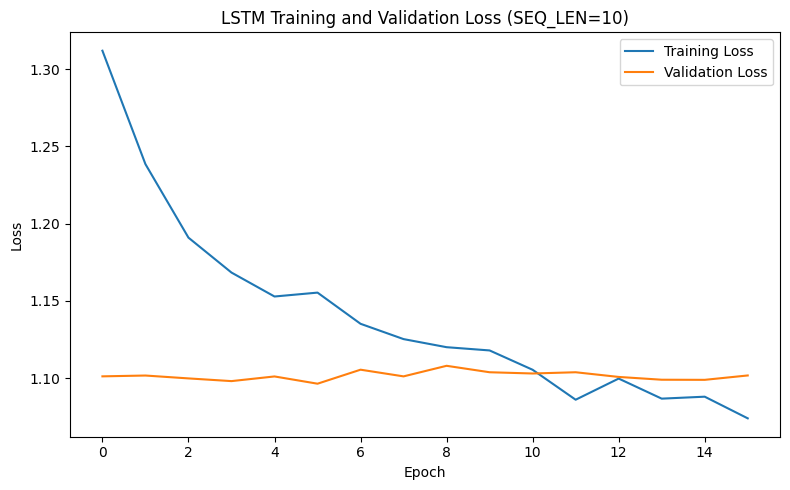

Saved -> results/figures/train_val_loss.png


In [18]:
os.makedirs("../results/figures", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"LSTM Training and Validation Loss (SEQ_LEN={SEQ_LEN})")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/train_val_loss.png", dpi=300)
plt.show()
print("Saved -> results/figures/train_val_loss.png")


## 17. Plot - confusion matrix

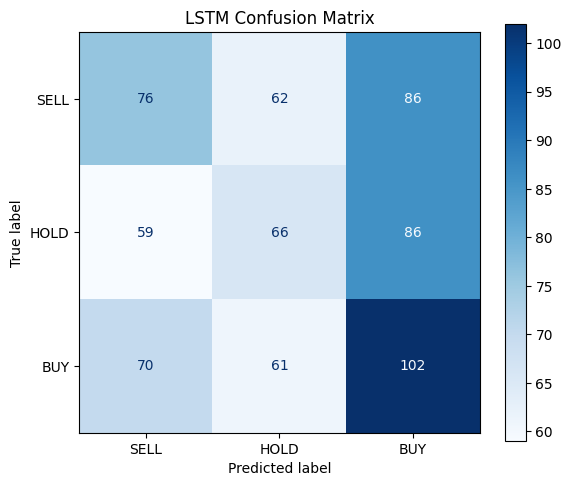

Saved -> results/figures/confusion_matrix.png


In [19]:
cm = confusion_matrix(y_test_seq, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix.png", dpi=300)
plt.show()
print("Saved -> results/figures/confusion_matrix.png")


## 18. Plot - model comparison (all models)

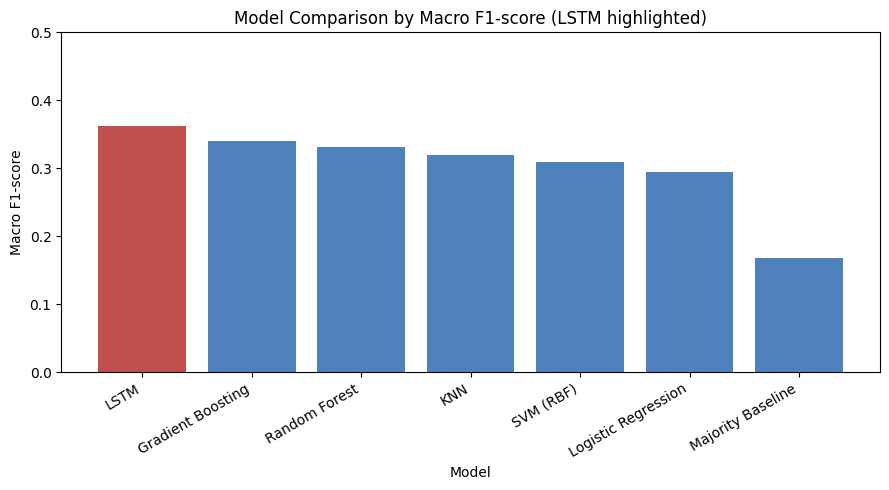

Saved -> results/figures/model_comparison.png


In [20]:
comparison_df = pd.read_csv("../results/metrics/model_comparison.csv")
comparison_df = comparison_df.sort_values("f1_macro", ascending=False)

colors = ["#C0504D" if m == "LSTM" else "#4F81BD" for m in comparison_df["model"]]
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["model"], comparison_df["f1_macro"], color=colors)
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Model Comparison by Macro F1-score (LSTM highlighted)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(0.5, comparison_df["f1_macro"].max() * 1.2))
plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png", dpi=300)
plt.show()
print("Saved -> results/figures/model_comparison.png")


## 19. Final summary

In [21]:
# Final summary to report (copy into the message to Tyra).
comparison_df = pd.read_csv("../results/metrics/model_comparison.csv")
best_row = comparison_df.sort_values("f1_macro", ascending=False).iloc[0]

print("=" * 56)
print("FINAL MODEL SUMMARY")
print("=" * 56)
print(f"Best model:            {best_row['model']}")
print(f"Best accuracy:         {best_row['accuracy']:.4f}")
print(f"Best macro F1-score:   {best_row['f1_macro']:.4f}")
print(f"LSTM accuracy:         {lstm_metrics['accuracy']:.4f}")
print(f"LSTM macro F1-score:   {lstm_metrics['f1_macro']:.4f}")
print(f"Feature columns used:  {len(feature_cols)} (no future/target columns)")
print(f"Target column used:    target_signal  (0=SELL, 1=HOLD, 2=BUY)")
print(f"Sequence length used:  {SEQ_LEN}")
print("=" * 56)


FINAL MODEL SUMMARY
Best model:            LSTM
Best accuracy:         0.3653
Best macro F1-score:   0.3622
LSTM accuracy:         0.3653
LSTM macro F1-score:   0.3622
Feature columns used:  30 (no future/target columns)
Target column used:    target_signal  (0=SELL, 1=HOLD, 2=BUY)
Sequence length used:  10


## Conclusion

All models score only modestly above the majority-class floor. Predicting the *next-day* direction of a single insurance stock from earthquake and financial features is genuinely hard - markets price in known information quickly and many drivers are unrelated to seismic activity.

The LSTM is reported as the time-series model and is compared honestly against the simpler baselines. If a tree-based model ever beats it on macro F1, that is an acceptable and reportable result: with a dataset this size, simpler models can generalise as well as or better than deep learning.

**Limitations:** single ticker (8766.T), ~3,380 daily rows (small for deep learning), and next-day direction is close to a random walk. See `docs/future_work.md` for next steps (more tickers, longer event windows, richer market features).